In [ ]:
# Displays S/N degradation as function of DC 

In [1]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# load stuff
repo_root = Path.cwd().resolve()
sim_pipeline = repo_root / "sim_pipeline"
if not sim_pipeline.is_dir():
    sim_pipeline = repo_root.parent / "sim_pipeline"
if str(sim_pipeline) not in sys.path:
    sys.path.insert(0, str(sim_pipeline))

# If you edited calculator.py in this session, reload so new names are visible
import modules.core.calculator as calculator
importlib.reload(calculator)

# read_s2n_cube_hdf5 (.hdf5 only) or load_s2n_cube (.hdf5 or .pkl)
read_s2n_cube_hdf5 = getattr(calculator, "read_s2n_cube_hdf5", calculator.load_s2n_cube)

In [2]:
# Path to S/N cubes HDF5 written by save_s2n_cube() in calculator.py
#s2n_hdf5_path = '/Users/eckhartspalding/Documents/git.repos/life_detectors/hdf5_testing/temp_s2n_sweep_planet_index_0000000_Nuniverse_1_Nstar_1_dist_10_Rp_1_Rs_1_Ts_5778_L_1.0_z_3_eclip_lon_135_eclip_lat_45_Stype_G/dc_5_qe_0.90_s2n_cube.hdf5'
s2n_hdf5_path = '/Users/eckhartspalding/Downloads/large_sweep_test/qe_0.50_s2n_cube.hdf5'


cube = read_s2n_cube_hdf5(s2n_hdf5_path)

# Primary array: shape (wavelength, DC, QE)
snr_cube = cube.snr
wavelength = cube.wavelength
dark_current = cube.dark_current
qe = cube.qe

print('-------- VITAL STATISTICS --------')
print("snr_cube shape (wavelength, DC, QE):", snr_cube.shape)
print("wavelength (um):", wavelength.min(), "-", wavelength.max())
print("dark_current (e/pix/s):", dark_current)
print("qe:", qe)
print('----------------------------------')

-------- VITAL STATISTICS --------
snr_cube shape (wavelength, DC, QE): (301, 5000, 4)
wavelength (um): 1.004987562112089 - 19.887162466508766
dark_current (e/pix/s): [0.000e+00 1.000e-03 2.000e-03 ... 4.997e+00 4.998e+00 4.999e+00]
qe: [0.2 0.3 0.4 0.5]
----------------------------------


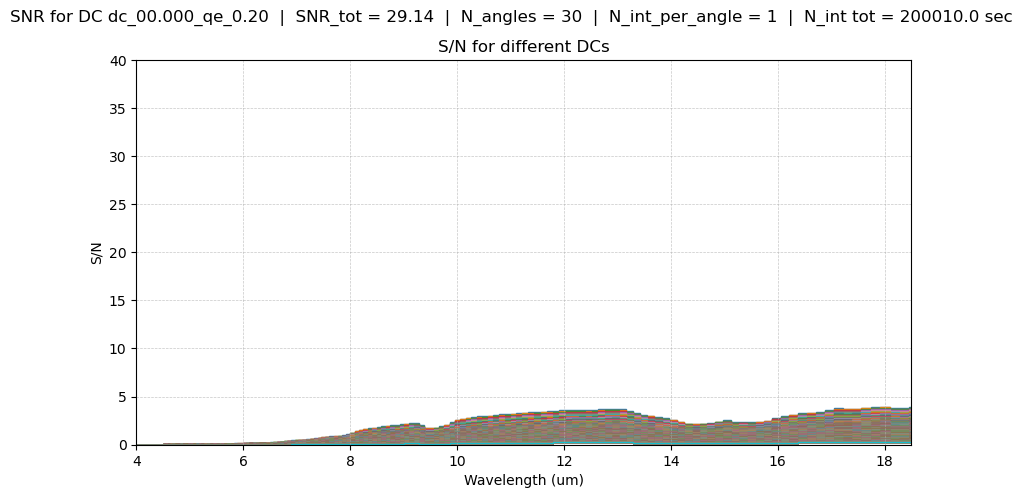

In [5]:
# S/N vs wavelength for one QE, varying DC
qe_idx = 0
plt.figure(figsize=(10, 5))
for i_dc, dc_val in enumerate(dark_current):
    if dc_val <= 0.5:
        label_this = f"{dc_val:.2f} e/pix/s"
    else:
        label_this = None
    plt.stairs(
        snr_cube[:, i_dc, qe_idx],
        edges=cube.wavel_bin_edges,
        label=label_this,
        #color='blue',
        #alpha=np.clip(0.5-dc_val, 0.1, 1),
    )
plt.grid(which="both", linestyle="--", linewidth=0.5, alpha=0.7)

plt.xlim(4, 18.5)
plt.ylim(0, 40)
plt.xlabel("Wavelength (um)")
plt.ylabel("S/N")
plt.suptitle(cube.base_titles[0, qe_idx])
plt.title('S/N for different DCs')
#plt.legend()
#plt.show()
plt.savefig('/Users/eckhartspalding/Downloads/junk_s2n_vs_dc.pdf')

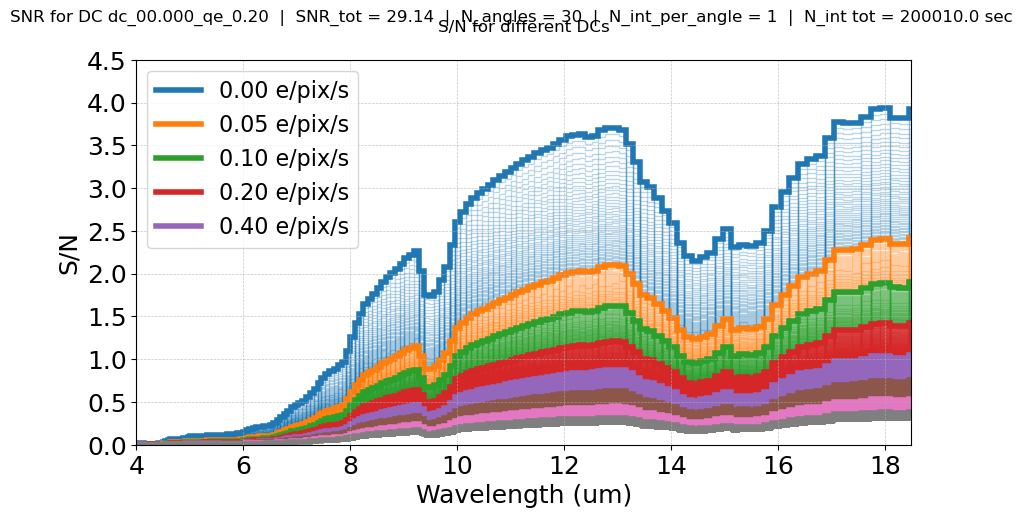

In [ ]:
# S/N vs wavelength for one QE, varying DC
from matplotlib import rcParams

qe_idx = 0
colors = rcParams["axes.prop_cycle"].by_key()["color"]
color_idx = -1
current_color = colors[0]

plt.figure(figsize=(10, 5))
for i_dc, dc_val in enumerate(dark_current):
    if dc_val <= 0.5:
        label_this = f"{dc_val:.2f} e/pix/s"
    else:
        label_this = None
    # advance color only on 0.05 DC steps; reuse for values in between
    if dc_val % 0.05 == 0:
        color_idx += 1
        current_color = colors[color_idx % len(colors)]
        plt.stairs(
            snr_cube[:, i_dc, qe_idx],
            edges=cube.wavel_bin_edges,
            label=label_this,
            linewidth=4,
            alpha=1,
            color=current_color,
        )
    else:
        plt.stairs(
            snr_cube[:, i_dc, qe_idx],
            edges=cube.wavel_bin_edges,
            linewidth=1,
            alpha=0.3,
            color=current_color,
        )
plt.grid(which="both", linestyle="--", linewidth=0.5, alpha=0.7)
plt.xlabel("Wavelength (um)", fontsize=18)
plt.ylabel("S/N", fontsize=18)
plt.title('S/N for different DCs', pad=20, fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlim(4, 18.5)
plt.ylim(0, 4.5)
plt.xlabel("Wavelength (um)")
plt.ylabel("S/N")
plt.suptitle(cube.base_titles[0, qe_idx])
plt.title('S/N for different DCs', pad=20)
plt.legend(fontsize=16)
#plt.show()
#plt.savefig('/Users/eckhartspalding/Downloads/junk_s2n_vs_dc.pdf')
plt.savefig('/Users/eckhartspalding/Downloads/junk_s2n_vs_dc.png', bbox_inches='tight', dpi=300)

/var/folders/wb/zn41c4yx58z1ktmcwgv62zyr0000gn/T/ipykernel_53526/3895301835.py:11: RuntimeWarning: All-NaN slice encountered
  max_dc_1d_at_qe_good_s2n = np.nanmax(


'\nfor i_dc, dc_val in enumerate(dark_current):\n    plt.stairs(\n        snr_cube[:, i_dc, qe_idx],\n        edges=cube.wavel_bin_edges,\n        label=f"DC = {dc_val:g} e/pix/s",\n    )\n'

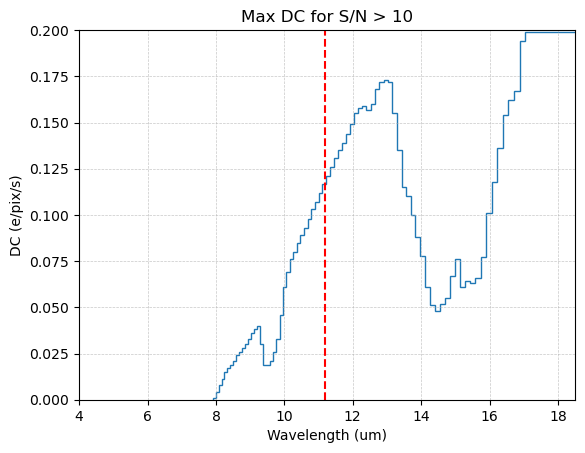

In [13]:
# plot the maximum DC for a given S/N = N at a given wavelength bin
# (wavelength, DC, QE)

s2n_min = 10.
qe_idx = 0
snr_2d_at_qe = snr_cube[:, :, qe_idx]          # shape (n_wavel, n_dc)
good = snr_2d_at_qe > s2n_min
# broadcast DC across wavelength rows
dc_grid = dark_current[np.newaxis, :]
# at each wavelength: max DC where S/N is good; else nan
max_dc_1d_at_qe_good_s2n = np.nanmax(
    np.where(good, dc_grid, np.nan),
    axis=1,
)


plt.clf()
plt.stairs(
    max_dc_1d_at_qe_good_s2n,
    edges=cube.wavel_bin_edges
    )
plt.grid(which="both", linestyle="--", linewidth=0.5, alpha=0.7)
plt.axvline(x=11.2, color='red', linestyle='--')
plt.xlim(4, 18.5)
plt.ylim(0, 0.2)
plt.xlabel("Wavelength (um)")
plt.ylabel("DC (e/pix/s)")
plt.title("Max DC for S/N > {:.2g} (at QE={:.2g})".format(s2n_min, cube.qe_values[qe_idx]) if hasattr(cube, 'qe_values') else "Max DC for S/N > {:.2g}".format(s2n_min))
#plt.legend()
#plt.show()
plt.savefig('/Users/eckhartspalding/Downloads/junk_max_dc_vs_wavelength.pdf')


#np.where(snr_cube[:, :, qe_idx] > s2n_min)


'''
for i_dc, dc_val in enumerate(dark_current):
    plt.stairs(
        snr_cube[:, i_dc, qe_idx],
        edges=cube.wavel_bin_edges,
        label=f"DC = {dc_val:g} e/pix/s",
    )
'''